In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm
import matplotlib as mpl

import torch
import dnnlib.util_v7 as util
from tqdm import tqdm
import pickle
from matplotlib.ticker import FuncFormatter
import pickle, types
from torch_utils import persistence

from PIL import Image

import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural_v7 import *
from plot_sim_results_v7 import *
from plot_sim_results_img_v7 import * 


import pandas as pd

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
colorgrad = "PuOr"

# 0. Some functions...

In [2]:
def plot_tau(T, out_imgs_tau, dset_samples, trial_idx, tau, title=None):
    # Plot True
    plot_frame(dset_samples, T, trial_idx)
    plt.suptitle(f'true, trial = {trial_idx}')
    plt.subplots_adjust(bottom=0.2)  # Make room for horizontal colorbar

    # Plot Simulated
    plot_frame(out_imgs_tau, T, trial_idx)
    if title is None:
        plt.suptitle(f'simulated- tau = {tau}')
    else:
        plt.suptitle(title)
    plt.subplots_adjust(bottom=0.2)

In [3]:
def recon_check_x0(encoder, trial_check, T_check, dset_samples):
    encoder = encoder.to(device).eval()
    X1_ori = dset_samples[trial_check][T_check,0,:,:]
    data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
    with torch.inference_mode():
        X1 = torch.from_numpy(data_flattent[trial_check][T_check,:]).to(device=device, dtype=torch.float32)
        X0 = encoder.rsample(X1)
    X0_back = X0.reshape(X0.shape[0], C, H, W)
    return X0_back[0,0,:,:].detach().cpu().numpy()

In [4]:
def recon_check_x0_allT(encoder, trial_check, dset_samples):
    encoder = encoder.to(device).eval()
    X1_ori = dset_samples[trial_check][T_check,0,:,:]
    data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
    with torch.inference_mode():
        X1 = torch.from_numpy(data_flattent[trial_check]).to(device=device, dtype=torch.float32)
        X0 = encoder.rsample(X1)
    X0_back = X0.reshape(X0.shape[0], C, H, W)
    return X0_back.detach().cpu().numpy()

In [5]:
def mu_group_recon(bias,
                   loading_np: np.ndarray,
                   mu_all: np.ndarray,
                   mu_idx=None,             # int | list[int] | np.ndarray | slice | None
                   H: int = 28,
                   W: int = 28,
                   mean_img: np.ndarray = None,
                   clip=None):
    D = loading_np.shape[0]
    assert loading_np.ndim == 2
    K_load = loading_np.shape[1]          # number of latent dims in loading
    N, K_mu = mu_all.shape               # number of latent dims in mu_all
    assert H * W == D

    # normalize mu_idx to an integer index array IN LATENT SPACE
    if mu_idx is None:
        idx = np.arange(min(K_load, K_mu))
    elif isinstance(mu_idx, slice):
        idx = np.arange(min(K_load, K_mu))[mu_idx]
    else:
        arr = np.asarray(mu_idx)
        if arr.dtype == bool:
            idx = np.flatnonzero(arr)
        else:
            idx = arr.astype(int, copy=False).ravel()

    # sanity: all requested dims must exist in both loading and mu_all
    max_idx = int(idx.max()) if idx.size > 0 else -1
    assert max_idx < K_load, f"mu_idx uses dim {max_idx}, but loading has only {K_load} cols"
    assert max_idx < K_mu,   f"mu_idx uses dim {max_idx}, but mu_all has only {K_mu} cols"

    A_sub  = loading_np[:, idx]     # (D, K_sel)
    mu_sub = mu_all[:, idx]         # (N, K_sel)
    recon_flat = mu_sub @ A_sub.T   # (N, D)

    if mean_img is not None:
        mean_flat = mean_img.reshape(-1)
        assert mean_flat.size == D
        recon_flat = recon_flat + mean_flat

    recon_flat = recon_flat + bias
    recon = recon_flat.reshape(N, H, W)
    if clip is not None:
        lo, hi = clip
        recon = np.clip(recon, lo, hi)
    return recon


# 1. Read Data

In [6]:
folder_data = 'out/ball/t_detach/data'
useCov = False

dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
cov_static_samples = np.load(folder_data + "/cov_static_trunc_only.npz", allow_pickle=True)
dset_samples = to_list_of_arrays(dataset_samples['samples'])
cov_stat_samples = to_list_of_arrays(cov_static_samples['samples'])

In [7]:
is_image = (np.asarray(dset_samples[0]).ndim == 4)
if is_image:
    _, C, H, W = np.asarray(dset_samples[0]).shape
T_min = min(arr.shape[0] for arr in dset_samples)
T_max = max(arr.shape[0] for arr in dset_samples)

In [8]:
eps = 1e-2
padded = [np.pad(a, ((0, T_max-a.shape[0]), (0,0), (0,0), (0,0)), mode='constant', constant_values=np.nan)
          for a in dset_samples]                                              # -> (n_trial, T_max, C, H, W)
stacked = np.stack(padded, axis=0)
min_img = np.nanmin(stacked, axis=(0,1))                                      # shape (C,H,W)
max_img = np.nanmax(stacked, axis=(0,1))                                      # shape (C,H,W)
clamp_range = np.stack([min_img - eps, max_img + eps], axis=0).astype(np.float32)  # shape (2,C,H,W)

In [9]:
TRIAL_IDX = 0
T = T_max

In [10]:
data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
data_flattent_all = np.concatenate(data_flattent, axis=0)

# 2. Read Models

In [11]:
folder_ref = 'out/ball/t_detach/00000-ball_dim50_lag0_none-prr-uncond-regularFM-gpus1-batch256-fp32'
folder = 'out/ball/t_detach/00012-ball_dim50_lag3_none-prr-uncond-regularFM-gpus1-batch256-fp32'

_, _, encoder_ref, _ = read_model(folder_ref, '/network-snapshot-004264.pkl')
flow_net4, dyn_net4, encoder4, lag = read_model(folder, '/network-snapshot-004264.pkl')

apply_posthoc_alignment(encoder4, encoder_ref)

Aligning signs for 105 columns.
Target encoder successfully patched.


In [12]:
print("k_max =", encoder4.k_max, "use_pop_stats =", encoder4.use_pop_stats)

k_max = 200 use_pop_stats = True


In [13]:
# check reconstruction
trial_check = 0
T_check = 0
X0_back4 = recon_check_x0(encoder4, trial_check, T_check, dset_samples = dset_samples)

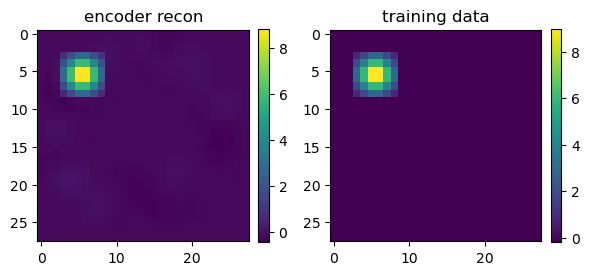

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(6, 5))

im1 = axs[0].imshow(X0_back4)
fig.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)  # smaller, aligned
axs[0].set_title('encoder recon')

im2 = axs[1].imshow(dset_samples[trial_check][T_check,0,:,:])
fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)  # same settings
axs[1].set_title('training data')

plt.tight_layout()
plt.show()

# 3. Simulate Trajectories

In [15]:
TRIAL_IDX = 0
n_step = T_max

## 3.1 Data space (tau = 1.0)

In [16]:
tau = 1.0
traj_sim_tau1_flattent, lag_cov_list = generate_traj_image_onthefly(dyn_net4.to(device),
                                                                    dset_samples, n_step,
                                                                    tau, device, lag,
                                                                    include_x0_tau=False,
                                                                    oracle=False,
                                                                    flow_net=None,
                                                                    clamp_range=clamp_range
                                                                    )

100%|███████████████████████████████████████████| 46/46 [00:02<00:00, 17.52it/s]


In [17]:
out_imgs_tau1 = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau1_flattent]

/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt/plot_sim_results_img_v7.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


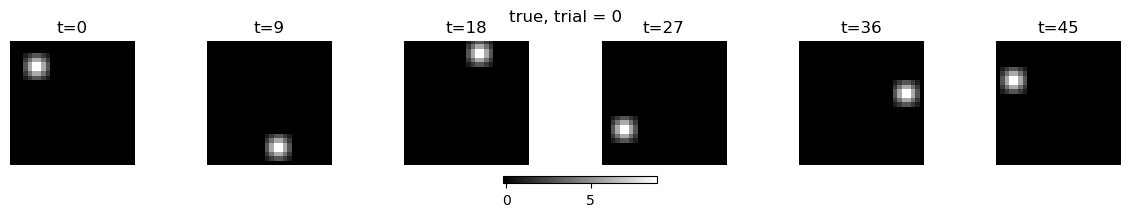

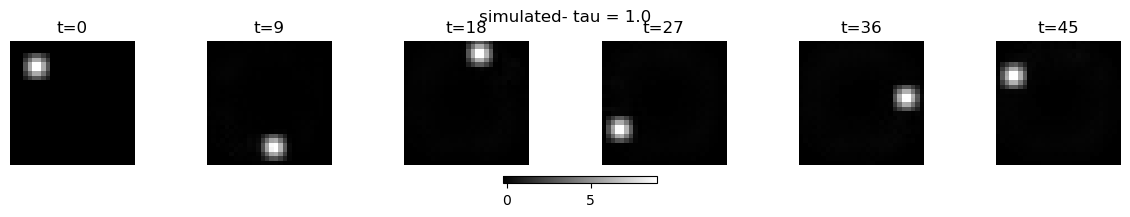

In [18]:
plot_tau(n_step, out_imgs_tau1, dset_samples, trial_idx = TRIAL_IDX, tau = 1.0)

## 3.2 Latent space (tau = 0.0)

In [19]:
out_imgs_tau0_flow_flatten = proj_to_latent(out_imgs_tau1, flow_net4.to(device), 0.0, device)
out_imgs_tau0_flow = [arr.reshape(arr.shape[0], C, H, W) for arr in out_imgs_tau0_flow_flatten ]

100%|███████████████████████████████████████████| 10/10 [00:01<00:00,  5.65it/s]


In [20]:
tau = 0.0
traj_sim_tau0_flattent, _ = generate_traj_image_onthefly(dyn_net4.to(device),
                                                         dset_samples, n_step,
                                                         tau, device, lag,
                                                         include_x0_tau=False,
                                                         oracle=False,
                                                         flow_net=flow_net4.to(device),
                                                         clamp_range=clamp_range
                                                         )
out_imgs_tau0 = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau0_flattent ]

100%|███████████████████████████████████████████| 46/46 [00:03<00:00, 14.65it/s]


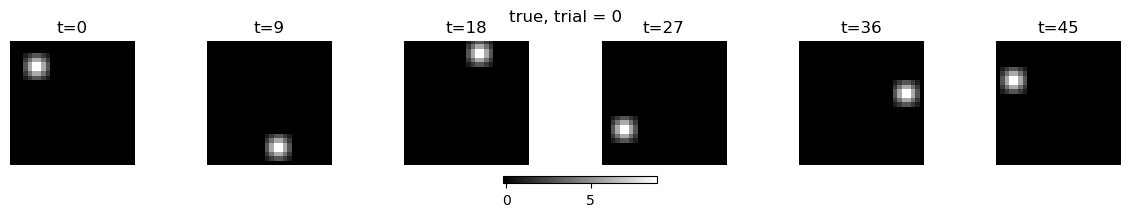

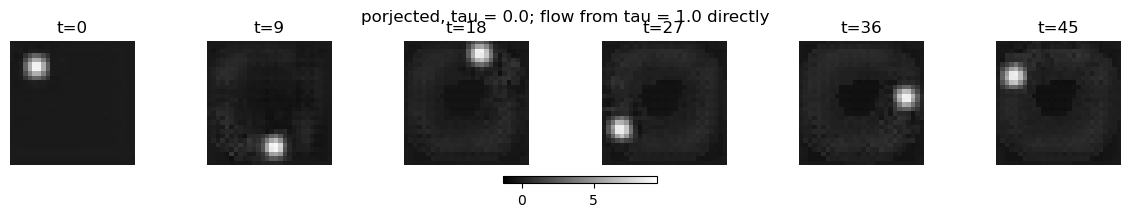

In [21]:
plot_tau(T, out_imgs_tau0_flow, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'porjected, tau = 0.0; flow from tau = 1.0 directly')

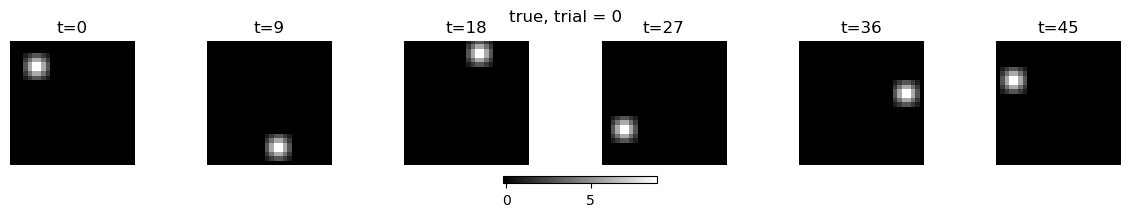

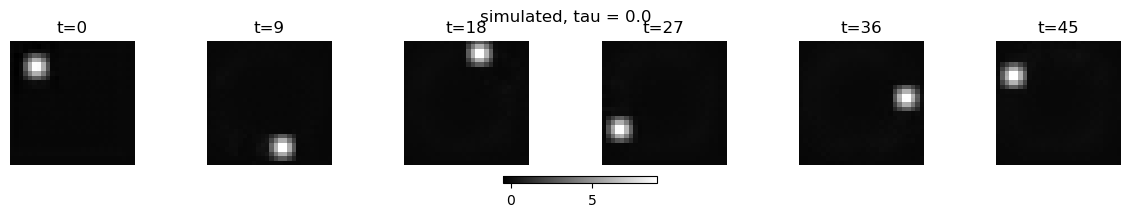

In [22]:
plot_tau(T, out_imgs_tau0, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'simulated, tau = 0.0')

# 4. Latent space

In [23]:
data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]

## 4.1 directly from encoder: mu(x_data)

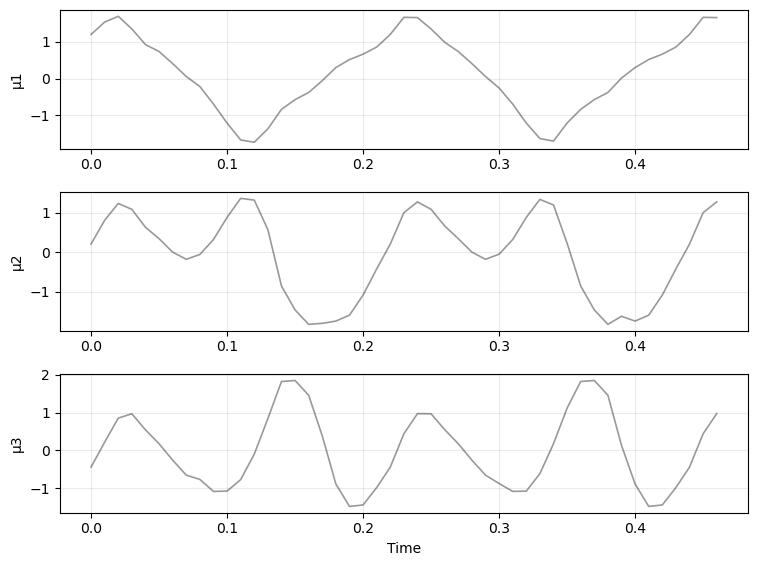

In [24]:
dim_to_keep = 3
mu_keep4 = get_mu_from_encoder(encoder4, data_flattent, dim_to_keep, TRIAL_IDX)
plot_latent_time_series([mu_keep4], alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)

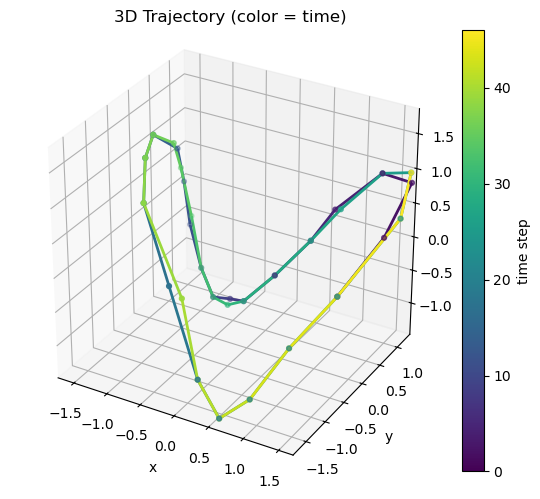

In [25]:
plot_traj_3d(mu_keep4)

In [26]:
mu_tmp, d, L, loading, bias = latent_mu(dset_samples, encoder4.to(device), dim_to_keep, device, fullRes = True)
L_np = L.detach().cpu().numpy()
d_np = d.detach().cpu().numpy()
loading_np = loading.detach().cpu().numpy()
mu_all = get_mu_from_encoder(encoder4, data_flattent, 28*28, TRIAL_IDX)

In [27]:
k_max = 200
k_target = 50
loading_norm_all = torch.norm(loading[:,0:k_max], dim= 0).detach().cpu().numpy()
energy = loading_norm_all ** 2 
cum_energy = np.cumsum(energy)
K_eff = 1 + np.searchsorted(cum_energy, 0.95 * cum_energy[-1])

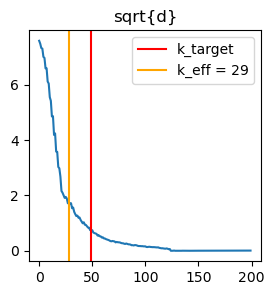

In [28]:
fig = plt.figure(figsize=(3, 3))
plt.plot(np.sqrt(d_np[0:k_max]))
plt.axvline(x=k_target-1, color='red', label = 'k_target')
plt.axvline(x=K_eff-1, color='orange', label = 'k_eff = ' + str(K_eff))
plt.title('sqrt{d}');
plt.legend()

Basically, $\sqrt{d_i}$ is loading column norm

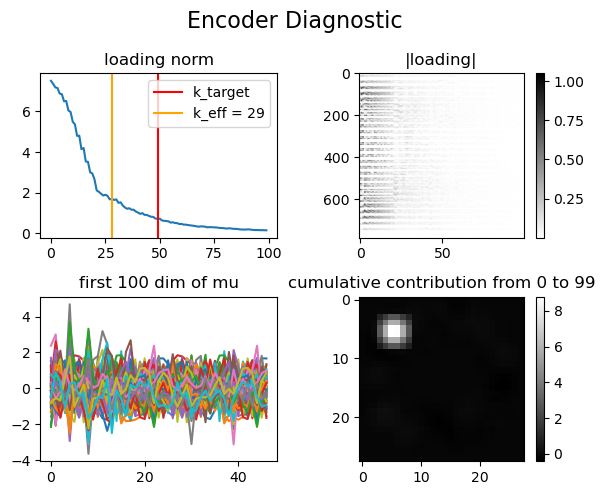

In [29]:
k_max = 200
dim_check_most = 100
k_target = 50
rows = loading.shape[0]
cols = dim_check_most
dim_check = np.arange(dim_check_most)
rec = mu_group_recon(bias.detach().cpu().numpy(), loading_np, mu_all, dim_check, H=28, W=28)
ball_idx = 0

fig, axs = plt.subplots(2, 2, figsize=(6, 5))
axs[0, 0].plot(loading_norm_all[:dim_check_most])
axs[0, 0].axvline(x=k_target-1, color='red', label = 'k_target')
axs[0, 0].axvline(x=K_eff-1, color='orange', label = 'k_eff = ' + str(K_eff))
axs[0, 0].set_title('loading norm')
axs[0, 0].legend()

im1 = axs[0, 1].imshow(np.abs(loading_np[:, 0:dim_check_most]), cmap='gray_r', aspect=cols / rows)
axs[0, 1].set_title('|loading|')
fig.colorbar(im1, ax=axs[0, 1])

axs[1, 0].plot(mu_all[:, :dim_check_most])
axs[1, 0].set_title('first ' + str(dim_check_most) + " dim of mu")

# Plot 4: cumulative contribution
im2 = axs[1, 1].imshow(rec[ball_idx], cmap='gray')
axs[1, 1].set_title('cumulative contribution from ' + str(dim_check[0]) + ' to ' + str(dim_check[-1]))
fig.colorbar(im2, ax=axs[1, 1])

fig.suptitle('Encoder Diagnostic', fontsize=16)
plt.tight_layout()
plt.show()

## 4.2 flowed/ project

In [30]:
dim_to_keep = 3
latent_traj_list = proj_to_latent(dset_samples, flow_net4.to(device), 0.0, device)

100%|███████████████████████████████████████████| 10/10 [00:01<00:00,  6.42it/s]


In [31]:
latent_traj_list_enc = []
for ii in range(len(dset_samples)):
    latent_traj_list_enc.append(recon_check_x0_allT(encoder4, ii, dset_samples))

In [32]:
# mu_traj_sim, d, L, loading, bias = latent_mu(latent_traj_list_enc, encoder4.to(device), dim_to_keep, device, fullRes = True)
mu_traj_sim, d, L, loading, bias = latent_mu(latent_traj_list, encoder4.to(device), dim_to_keep, device,
                                             fullRes = True, resid_tol=1e-15)

In [33]:
data_flow = [arr.reshape(arr.shape[0], C, H, W) for arr in latent_traj_list ]
data_enc = [arr.reshape(arr.shape[0], C, H, W) for arr in latent_traj_list_enc ]

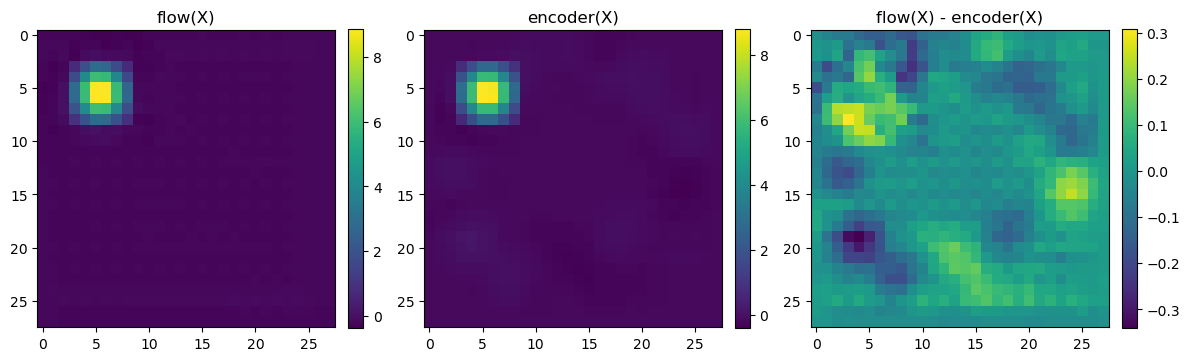

In [34]:
trial_check = 0
T_check = 0
fig, axs = plt.subplots(1, 3, figsize=(12, 10))

im1 = axs[0].imshow(data_flow[trial_check][T_check,0])
fig.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)  # smaller, aligned
axs[0].set_title('flow(X)')

im2 = axs[1].imshow(data_enc[trial_check][T_check,0])
fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)  # smaller, aligned
axs[1].set_title('encoder(X)')

im3 = axs[2].imshow(data_flow[trial_check][T_check,0] - data_enc[trial_check][T_check,0])
fig.colorbar(im3, ax=axs[2], fraction=0.046, pad=0.04)  # smaller, aligned
axs[2].set_title('flow(X) - encoder(X)')

plt.tight_layout()
plt.show()

Text(0.5, 0.98, 'flowed latent trajc for each trial')

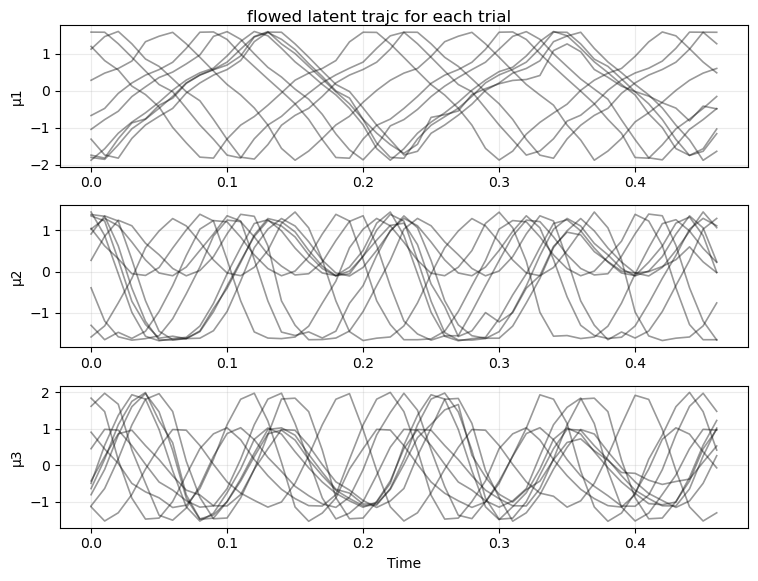

In [35]:
mu_traj_flow_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
plot_latent_time_series(mu_traj_flow_np, alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)
plt.suptitle('flowed latent trajc for each trial')

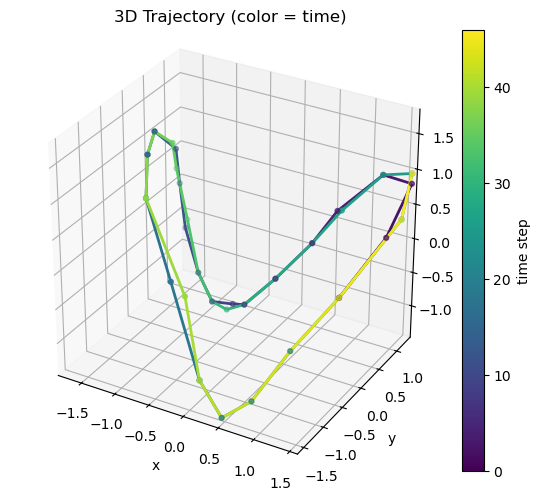

In [36]:
plot_traj_3d(mu_traj_flow_np[TRIAL_IDX][:,0:3])

### Flow field in mu space...

In [37]:
dim_to_keep = 3  # μ-dims you kept elsewhere
mu_pts, v_mu = compute_mu_velocity_field(
    latent_traj_list=latent_traj_list,
    dyn_net=dyn_net4,
    encoder=encoder4,
    device=device,
    dim_preserve=dim_to_keep,
    lag=lag,
    t_plot=0.0,
)

# plot_mu_velocity_2d(
#     mu_pts,
#     v_mu,
#     dims=(0, 1),
#     title="flowed: mu1–mu2 field (tau =0.0)",
#     arrow_frac=0.05,   # physical length
#     arrow_size=1.2,    # make arrows fatter/heads larger
#     max_points=3000,
#     linewidth=1.5,
# )

# plot_mu_velocity_3d(
#     mu_pts,
#     v_mu,
#     dims=(0, 1, 2),
#     title="flowed: mu1–mu2-mu3 field (tau =0.0)",
#     arrow_frac=0.1,    # physical length
#     arrow_size=1.5,    # bigger heads/thicker shafts
#     max_points=3000,
# )

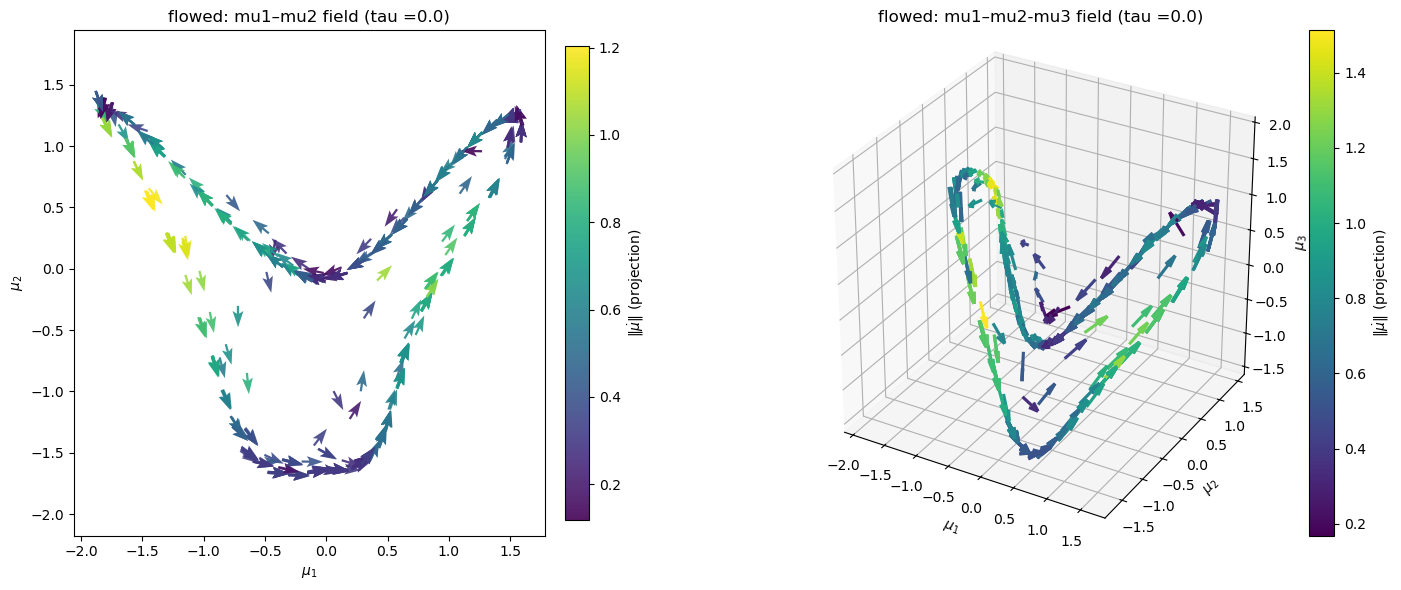

In [38]:
plot_mu_velocity_panel(mu_pts, v_mu,
                       title_2d = "flowed: mu1–mu2 field (tau =0.0)",
                       title_3d = "flowed: mu1–mu2-mu3 field (tau =0.0)",
                       arrow_frac_2d=0.05,
                       arrow_size_2d=1.2,
                       linewidth_2d=1.5,
                       
                       arrow_frac_3d=0.1,
                       arrow_size_3d=1.5,
                       linewidth_3d=1.5,
                       base_arrow_length_ratio_3d=0.3,
                       )

## 4.3 simulated

In [39]:
dim_to_keep = 3
mu_traj_sim, d, L, loading, bias = latent_mu(traj_sim_tau0_flattent, encoder4.to(device), dim_to_keep, device, fullRes = True)

Text(0.5, 0.98, 'simulated latent trajc for each trial')

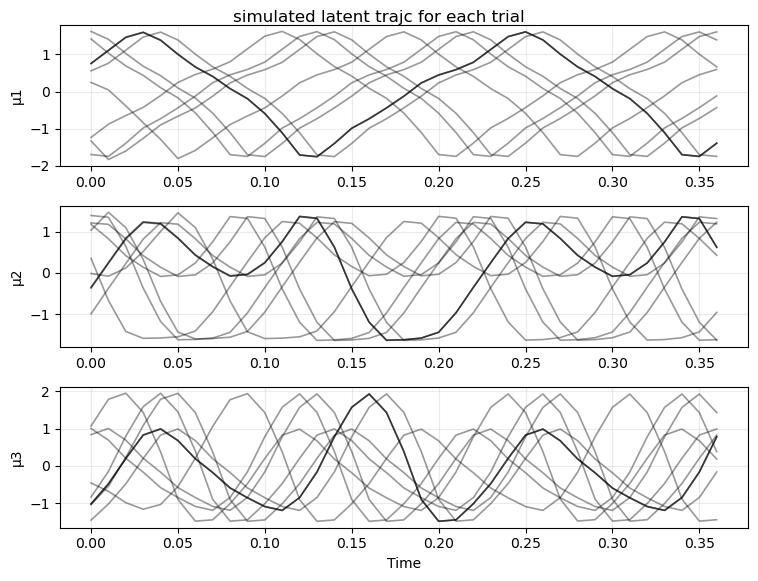

In [40]:
mu_traj_sim_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
mu_traj_sim_np_plot = [mu_traj_sim_np[ii][10:,:] for ii in range(len(mu_traj_sim_np))]
plot_latent_time_series(mu_traj_sim_np_plot, alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)
plt.suptitle('simulated latent trajc for each trial')

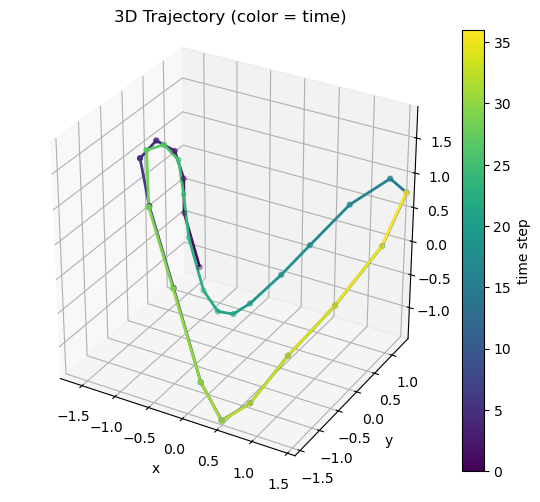

In [41]:
plot_traj_3d(mu_traj_sim_np_plot[TRIAL_IDX][:,0:3])

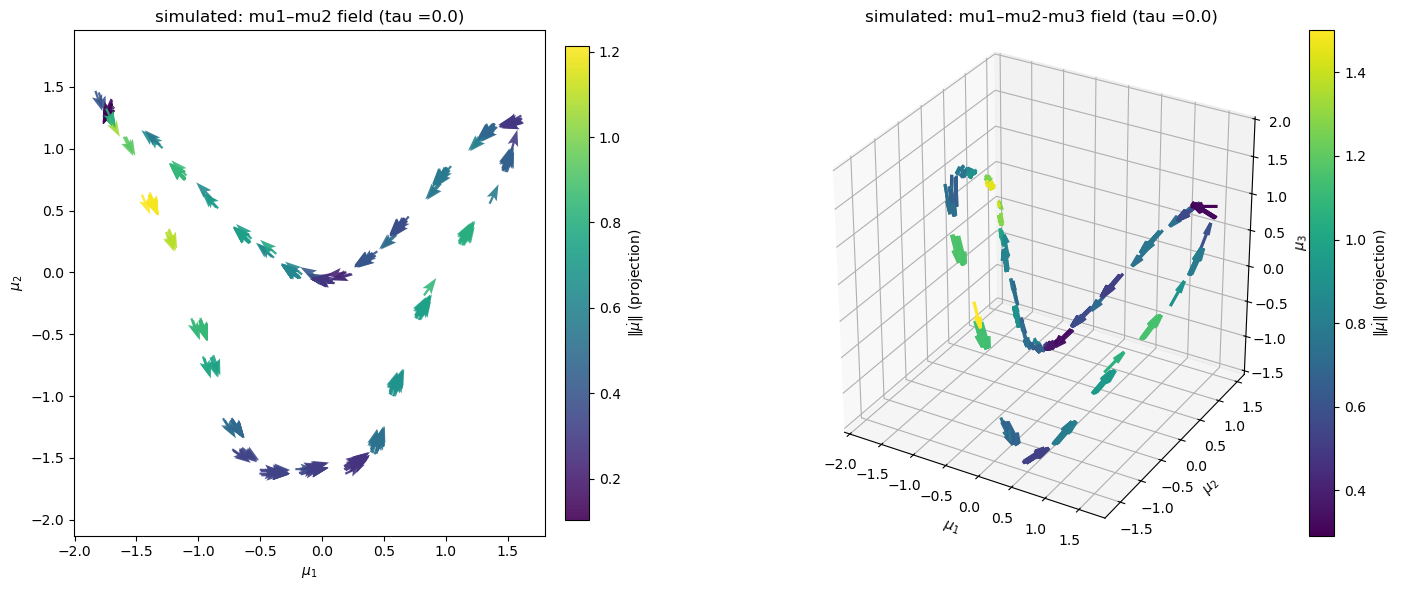

In [42]:
dim_to_keep = 3  # μ-dims you kept elsewhere
mu_pts, v_mu = compute_mu_velocity_field(
    latent_traj_list=traj_sim_tau0_flattent,
    dyn_net=dyn_net4,
    encoder=encoder4,
    device=device,
    dim_preserve=dim_to_keep,
    lag=lag,
    t_plot=0.0,
)

plot_mu_velocity_panel(mu_pts, v_mu,
                       title_2d = "simulated: mu1–mu2 field (tau =0.0)",
                       title_3d = "simulated: mu1–mu2-mu3 field (tau =0.0)",
                       arrow_frac_2d=0.05,
                       arrow_size_2d=1.2,
                       linewidth_2d=1.5,
                       
                       arrow_frac_3d=0.1,
                       arrow_size_3d=1.5,
                       linewidth_3d=1.5,
                       base_arrow_length_ratio_3d=0.3,
                       )

# Appendix: put all plots together

In [43]:
TRIAL_IDX = 9
T = T_max

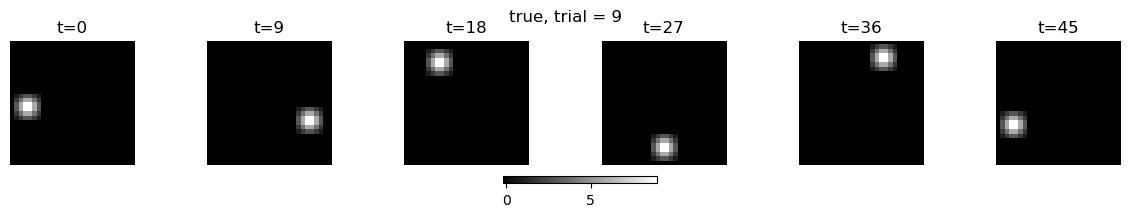

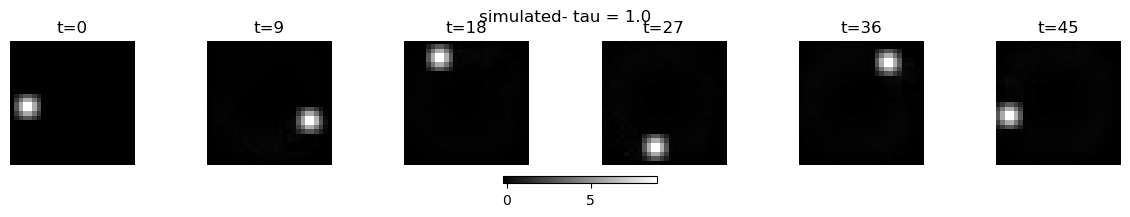

In [44]:
plot_tau(T, out_imgs_tau1, dset_samples, trial_idx = TRIAL_IDX, tau = 1.0)

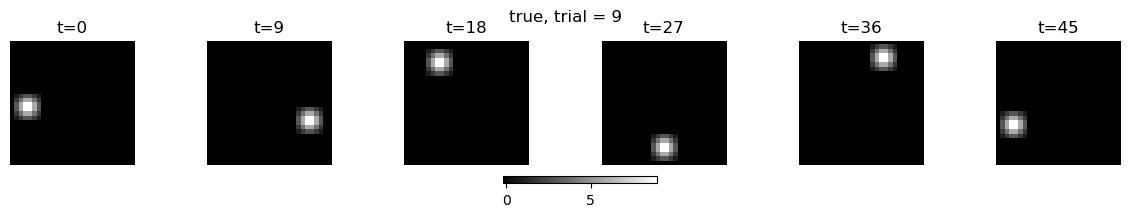

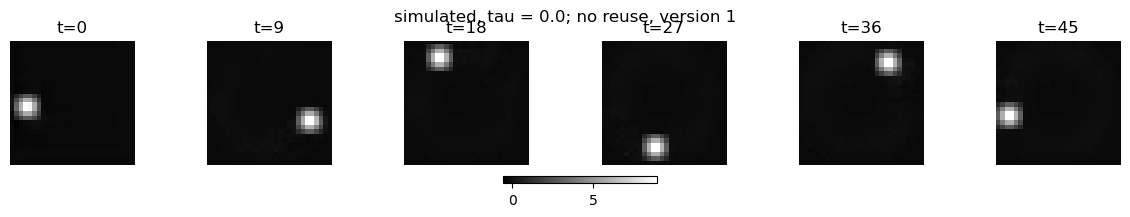

In [45]:
plot_tau(T, out_imgs_tau0, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'simulated, tau = 0.0; no reuse, version 1')